In [56]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [57]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on: {device}")

Running on: mps


In [58]:
folder_name = "Spot-Defect Images(SDI)"
# ======================================================
# 自动拼接 Mac 下载文件夹绝对路径
DATA_ROOT = os.path.join(os.path.expanduser("~/Downloads"), folder_name)
print(f"完整数据集路径：{DATA_ROOT}")
print(f"路径是否存在：{os.path.exists(DATA_ROOT)}")

完整数据集路径：/Users/chris/Downloads/Spot-Defect Images(SDI)
路径是否存在：True


In [59]:
class NEUMetalDataset(Dataset):
    def __init__(self, root_dir, img_size=64):
        self.root = root_dir
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(1),
            transforms.ToTensor(), # range [0,1]
        ])
        image_exts = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}
        self.paths = [
            os.path.join(current_dir, filename)
            for current_dir, _, filenames in os.walk(root_dir)
            for filename in filenames
            if os.path.splitext(filename)[1].lower() in image_exts
        ]
        self.paths.sort()
        print(f"Total metal images: {len(self.paths)}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        im = Image.open(self.paths[idx]).convert("L")
        return self.transform(im)

Total metal images: 20


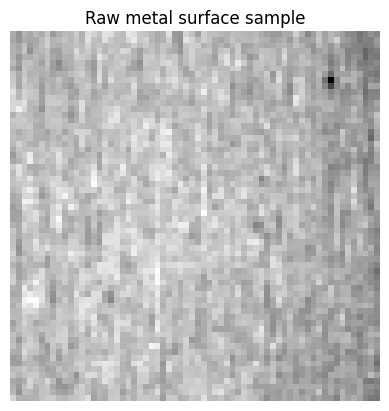

In [60]:
dataset = NEUMetalDataset(root_dir=DATA_ROOT, img_size=64)
dl = DataLoader(dataset, batch_size=6, shuffle=True, num_workers=0)

sample = next(iter(dl))
plt.imshow(sample[0,0].cpu(), cmap="gray")
plt.title("Raw metal surface sample")
plt.axis("off")
plt.show()

In [61]:
class SimpleVAE(nn.Module):
    def __init__(self, in_ch=1, latent_ch=4):
        super().__init__()
        # encoder: 64×64 → 4×16×16 latent
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch,16,4,2,1), nn.ReLU(),
            nn.Conv2d(16,32,4,2,1), nn.ReLU(),
            nn.Conv2d(32,latent_ch,3,padding=1),
        )
        # decoder: latent → 64×64图像
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(latent_ch,32,4,2,1), nn.ReLU(),
            nn.ConvTranspose2d(32,16,4,2,1), nn.ReLU(),
            nn.Conv2d(16,in_ch,3,padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        z = self.enc(x)
        return z

    def decode(self, z):
        return self.dec(z)


In [62]:
class LatentUNet(nn.Module):
    def __init__(self, latent_ch=4, cond_dim=4, time_dim=32):
        super().__init__()
        self.time_emb = nn.Sequential(nn.Linear(1,time_dim), nn.ReLU(), nn.Linear(time_dim,time_dim))
        self.cond_proj = nn.Linear(cond_dim, time_dim)

        self.in_conv = nn.Conv2d(latent_ch+time_dim, 32, 3, padding=1)
        self.down = nn.Conv2d(32,64,4,2,1)
        self.mid = nn.Conv2d(64,64,3,padding=1)
        self.up = nn.ConvTranspose2d(64,32,4,2,1)
        self.out = nn.Conv2d(32, latent_ch, 3, padding=1)

    def forward(self, z_latent, t, texture_cond):
        B,C,H,W = z_latent.shape
        t_emb = self.time_emb((t.view(B,1).float() / 200.0).clamp(0, 1))
        c_emb = self.cond_proj(texture_cond)
        emb = (t_emb + c_emb).view(B,-1,1,1).repeat(1,1,H,W)

        x = torch.cat([z_latent, emb], dim=1)
        x1 = F.relu(self.in_conv(x))
        x2 = F.relu(self.down(x1))
        x2 = F.relu(self.mid(x2))
        xu = F.relu(self.up(x2))
        pred_noise = self.out(xu)
        return pred_noise

In [63]:
class LDMSchedulerAdaNI:
    def __init__(self, T=200):
        self.T = T
        self.beta = torch.linspace(0.0001,0.02, T).to(device)
        self.alpha = 1-self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    # AdaNI：根据磨损时间差delta_d，返回起始噪声时间步t_start
    def adani_get_tstart(self, delta_d):
        if abs(delta_d) <=3:
            return int(self.T*0.20)
        elif 3< abs(delta_d) <=7:
            return int(self.T*0.50)
        else:
            return int(self.T*0.80)

    # latent空间前向加噪 q(zt|z0)
    def add_noise_latent(self, z0, t):
        B = z0.shape[0]
        abar = self.alpha_bar[t].view(B,1,1,1)
        eps = torch.randn_like(z0)
        zt = torch.sqrt(abar)*z0 + torch.sqrt(1-abar)*eps
        return zt, eps

    # 标准反向去噪
    @torch.no_grad()
    def denoise_step(self, model, zt, t, texture_cond):
        B = zt.shape[0]
        t_tensor = torch.full((B,), t, device=device, dtype=torch.long)
        eps_pred = model(zt, t_tensor, texture_cond)
        beta_t = self.beta[t]
        a_t = self.alpha[t]
        abar_t = self.alpha_bar[t]
        coeff1 = 1.0/torch.sqrt(a_t)
        coeff2 = (1-a_t)/torch.sqrt(1-abar_t)
        z_next = coeff1 * (zt - coeff2*eps_pred)
        if t>0:
            z_next += torch.sqrt(beta_t)*torch.randn_like(z_next)
        return z_next

    @torch.no_grad()
    def pass1_adani_infer(self, model, z0_source, delta_d, texture_cond):
        t_start = self.adani_get_tstart(delta_d)
        t_start_tensor = torch.full((z0_source.shape[0],), t_start, device=device, dtype=torch.long)
        z = self.add_noise_latent(z0_source, t_start_tensor)[0]
        for t in reversed(range(0, t_start+1)):
            z = self.denoise_step(model, z, t, texture_cond)
        return z

    @torch.no_grad()
    def pass2_refine(self, model, z_pass1, z0_source, texture_cond):
        t_start_low = int(self.T*0.15)
        t_start_tensor = torch.full((z_pass1.shape[0],), t_start_low, device=device, dtype=torch.long)
        z = self.add_noise_latent(z_pass1, t_start_tensor)[0]
        for t in reversed(range(0, t_start_low+1)):
            z = self.denoise_step(model, z, t, texture_cond)
        return z


# 初始化模型
vae = SimpleVAE(in_ch=1, latent_ch=4).to(device)
unet = LatentUNet(latent_ch=4, cond_dim=4, time_dim=32).to(device)
scheduler = LDMSchedulerAdaNI(T=200)

opt_vae = torch.optim.Adam(list(vae.parameters()), lr=8e-4)
opt_unet = torch.optim.Adam(list(unet.parameters()), lr=1e-4)

In [64]:
print("==== Pre‑train VAE ====")
vae.train()
for ep in range(30):
    total_rec_loss = 0
    for x0 in dl:
        x0 = x0.to(device)
        z = vae.encode(x0)
        x_rec = vae.decode(z)
        loss_rec = F.mse_loss(x_rec, x0)
        opt_vae.zero_grad()
        loss_rec.backward()
        opt_vae.step()
        total_rec_loss += loss_rec.item()
    avg = total_rec_loss / len(dl)
    if (ep+1)%5==0:
        print(f"VAE epoch {ep+1}, rec loss {avg:.4f}")


==== Pre‑train VAE ====
VAE epoch 5, rec loss 0.0019
VAE epoch 10, rec loss 0.0017
VAE epoch 15, rec loss 0.0016
VAE epoch 20, rec loss 0.0018
VAE epoch 25, rec loss 0.0016
VAE epoch 30, rec loss 0.0015



==== Train LDM UNet ====
LDM epoch 10 | loss 1.0027
LDM epoch 20 | loss 1.0037
LDM epoch 30 | loss 0.9863
LDM epoch 40 | loss 0.9914
LDM epoch 50 | loss 0.9401


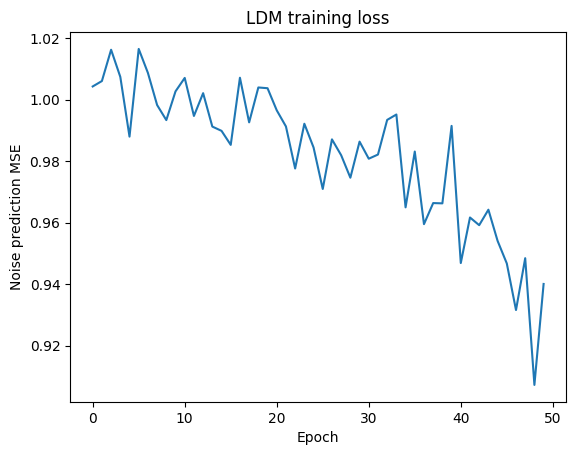

In [65]:
print("\n==== Train LDM UNet ====")
unet.train()
vae.eval()
loss_hist = []
for epoch in range(50):
    total_loss = 0.0
    for x0 in dl:
        x0 = x0.to(device)
        with torch.no_grad():
            z0 = vae.encode(x0)
            # 从原图 latent 提取纹理条件，训练和推理保持一致
            texture_cond = F.adaptive_avg_pool2d(z0, 1).flatten(1)

        B = z0.shape[0]
        t = torch.randint(0, scheduler.T, (B,), device=device)
        zt, eps_gt = scheduler.add_noise_latent(z0, t)
        eps_pred = unet(zt, t, texture_cond)
        loss = F.mse_loss(eps_pred, eps_gt)

        opt_unet.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
        opt_unet.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(len(dl), 1)
    loss_hist.append(avg_loss)
    if (epoch+1)%10 == 0:
        print(f"LDM epoch {epoch+1:2d} | loss {avg_loss:.4f}")

plt.plot(loss_hist)
plt.title("LDM training loss")
plt.xlabel("Epoch")
plt.ylabel("Noise prediction MSE")
plt.show()

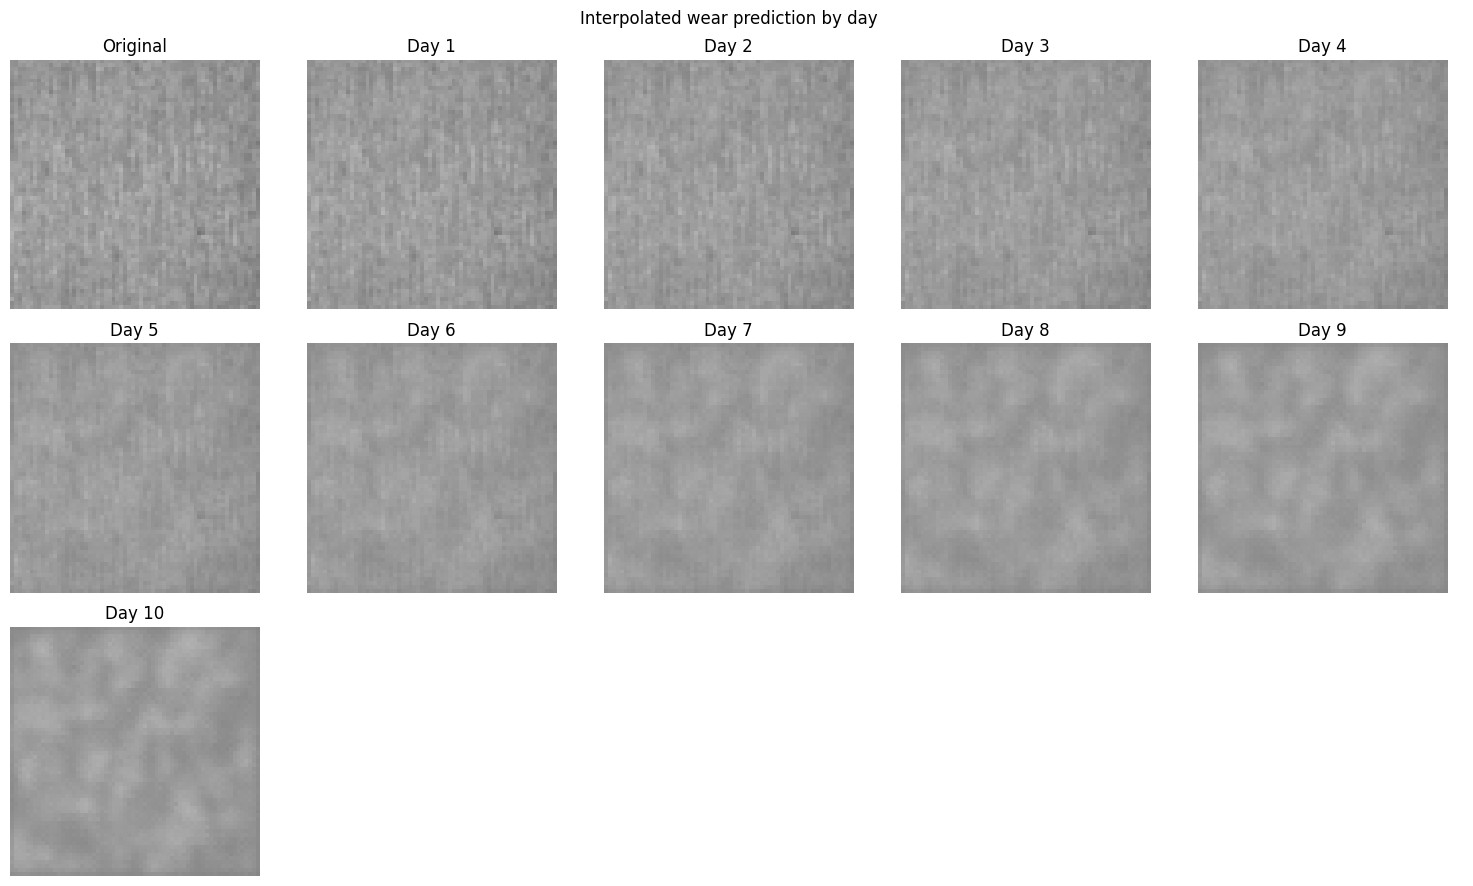

已展示原图及第 1 天至第 10 天，共 11 张图。
每日预测在图像空间线性插值，因此变化幅度连续；真实准确率仍需带时间标签的 SDI 数据验证。


In [69]:
# ========== 原图与每单位时间的磨损预测对比 ==========
# 修改这里即可改变预测时长（单位：天）
predict_delta_days = 10
source_index = 0

if len(dataset) == 0:
    raise RuntimeError("数据集为空，请检查 DATA_ROOT 和图像文件格式。")
if not 0 <= source_index < len(dataset):
    raise IndexError(f"source_index 必须在 0 到 {len(dataset) - 1} 之间。")
if predict_delta_days < 0:
    raise ValueError("predict_delta_days 不能为负数。")

# 固定随机种子，保证同一输入重复运行时结果一致
seed = 42
torch.manual_seed(seed)
if device.type == "mps":
    torch.mps.manual_seed(seed)

vae.eval()
unet.eval()
source_image = dataset[source_index].unsqueeze(0).to(device)

with torch.no_grad():
    source_latent = vae.encode(source_image)
    texture_cond = F.adaptive_avg_pool2d(source_latent, 1).flatten(1)
    target_latent = scheduler.pass1_adani_infer(
        unet,
        source_latent,
        predict_delta_days,
        texture_cond,
    )
    target_latent = scheduler.pass2_refine(
        unet,
        target_latent,
        source_latent,
        texture_cond,
    )
    target_image = vae.decode(target_latent).clamp(0, 1)

    # 在图像空间插值，避免非线性 VAE 解码导致第 1 天突然跳变
    day_values = torch.arange(predict_delta_days + 1, device=device, dtype=torch.float32)
    interpolation_weights = (day_values / max(predict_delta_days, 1)).view(-1, 1, 1, 1)
    source_images = source_image.expand(predict_delta_days + 1, -1, -1, -1)
    target_images = target_image.expand(predict_delta_days + 1, -1, -1, -1)
    predicted_images = torch.lerp(source_images, target_images, interpolation_weights).cpu()

columns = min(5, predict_delta_days + 1)
rows = (predict_delta_days + columns) // columns
fig, axes = plt.subplots(rows, columns, figsize=(3 * columns, 3 * rows), squeeze=False)
for day, image in enumerate(predicted_images):
    row, column = divmod(day, columns)
    axes[row, column].imshow(image[0], cmap="gray", vmin=0, vmax=1)
    axes[row, column].set_title("Original" if day == 0 else f"Day {day}")
    axes[row, column].axis("off")

for empty_index in range(predict_delta_days + 1, rows * columns):
    row, column = divmod(empty_index, columns)
    axes[row, column].axis("off")

plt.suptitle("Interpolated wear prediction by day")
plt.tight_layout()
plt.show()

print(f"已展示原图及第 1 天至第 {predict_delta_days} 天，共 {predict_delta_days + 1} 张图。")
print("每日预测在图像空间线性插值，因此变化幅度连续；真实准确率仍需带时间标签的 SDI 数据验证。")